In [7]:
import os
from dotenv import load_dotenv
from typing import Annotated, TypedDict
load_dotenv()

True

In [68]:
from langgraph.graph import StateGraph,  START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages

In [8]:
api_key = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = api_key

In [70]:
# Define state
class State(TypedDict):
    messages: Annotated[list[dict], add_messages]

In [71]:
# Setup LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0.7,
)

In [72]:
# Define the chatbot node
def chatbot(state:State):
  return {"messages":[llm.invoke(state["messages"])]}

In [73]:
# Create the state graph
graph=StateGraph(State)
graph.add_node("chatbot", chatbot)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

graph_compile=graph.compile()

In [75]:
result=graph_compile.invoke({"messages":[{"role":"user","content":"Hello, who are you?"}]})

d:\Ai Engineer_\LangGraphLearn\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


In [76]:
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'Hello! I am Gemini, a large language model created by Google. \n\nHow can I help you today?', 'extras': {'signature': 'Eq8GCqwGARFNMg8Ft7SMm9RHKQrDu01BI9NA+VhFOsEpD5Zg62KulORWgn9S7YcIZ2oQVUUOiubKAGviBhybUXMuNij1AGS9SMk46d83oX+cGTAnAdr91GE/Qtfvc5VgWpeZQYd1bFjDbbzRZ2wj5IC2v+ZP4bZCQ3+Ty+jCRNQhNZxy+G+cDeJ53EHwsXcTblMHCUIBGCvhZx1CBPoy4smwLMibnc3Ta4M2hjIH/LUkdUIYY7CuEwEhGKXM9Bx+xQ2xLC9SiFoiL3E6+K6s7YrmCx/aMpgW41EaptGAkaLntxYFI7m9ORZR3ggf68fUtU6GeysG5JcqgEkF+BrkoNHaofFW4GZcOzBDuENHt83XEOcjNdmeKDaA8e9bMSrnU+R8sLqVQgZKmAcJ6Of2kdW7H8bh7XC/HST3adHsCjbIWBXZNKQ0NL5yfjEDTncXFOOQP5oB+XXWl8vJ/TpQmJ93Nq5XWL9du0zmHHj8aTWZ1pHhWb3uw3I0Ril7cNhdUdGi3EQq0eF/zkAiK8gakuTHaEl6DIf9dVYHmPxYHQ4n9OB2MlkBhxTSxO5VAZ/oB+sjFV1NdCKeIfjUZeo7C85fFGdmh84CeV1qhJvBYo4SRyLd9NrDHHvVO7q4us9LvrBpiurCDfIjqZ+JzSenViuCxUFv5wjjQvh5zWsg8EefDl0BDQZkiYduQ1/RL3QsvtIqMVdzD7+3EC1iWshWJFqQ/lSlYAVyEeCsTENW8UyVVw1pdOjBaoAcknto9FFjGyXoeZQa7Imff7AYAZKbMWvdF+aWhGaSkn/i42yIJxui3voy9krWZDU3/nyM8aR9jD3PRVeyLSjiG9/YeLNFqk

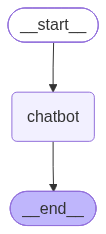

In [77]:
# visualize the graph
from IPython.display import Image
Image(graph_compile.get_graph().draw_mermaid_png())

In [ ]:
# add another node in the above workflow - summary the conversation

def summarize(state:State):
    summary_prompt = {"role": "user", "content": "Please provide a short summary of our conversation above."}
    
    summary = llm.invoke(state["messages"] + [summary_prompt])
    return {"messages": [summary]}

In [84]:
graph = StateGraph(State)
graph.add_node("chatbot", chatbot)
graph.add_node("summarize", summarize)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", "summarize")
graph.add_edge("summarize", END)

graph_compile = graph.compile()

In [85]:
res=graph_compile.invoke({"messages":[{"role":"user","content":"Hello, who are you?"}]})

d:\Ai Engineer_\LangGraphLearn\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
d:\Ai Engineer_\LangGraphLearn\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


In [89]:
print(res["messages"][-1].content)
# This can be example of prompt chaining workflow where the output of one node is used as input to another node. In this case, the chatbot node generates a response based on the user's input, and then the summarize node generates a summary of the conversation.

[{'type': 'text', 'text': 'Here is a short summary of our conversation so far:\n\nYou asked who I am, and I introduced myself as Gemini, an AI created by Google, and offered my assistance.', 'extras': {'signature': 'EpsJCpgJARFNMg9d5diH32OlKJWL/r+TNApzxykSgQDVrvQ7XV7oeYBNuG+hon79tqKG051D4dV2I3la0vRrZ138h7KVapY6CikLfMimFacVCu406SpJBeZl77SJFqdV18/cLIHR+yjY7kTj/mLNPEu8R2s3nncuCm0v531PBg0sBQjv4A7/nDe9ZiWqWSuXT38GdGokJx/VRCNM8Cwfuy979AZ+IgsUbACa5ls/FXgwptsuu77inuCdTl85OSkSRm3fn6OkjhzDO2pRbZUeG5hwldH+FostODP4vTK1rRxcT2CpByloqa4ZQ9bMcjo8G1+J1Q5eZiy9Iyr/o5wF0TlPMlgnC1Cz63eR1anfxc9MtGmItpmmnNwodIzXJSCXDVmcfJHTO21LnoOXdChCOR0CF6+Ry8wIrw+j4yOnetooZNy7qca0Zy/DUgq14g+KPIc5abrYt0itgvehunQ8ZAFFF4j/EHGx4K4lCCOifXpzb4FEw6jqQi78SNmHsZVhXre1q4UlznO2BYhDT7jmfkJE7QdmCMLhsUi+2NiY6HxvghqwC4P5H6XFZsYNHNzCN8KKPHdiW8546HdyJMN9Is7RKgNQ7IsvaTLahWBXmGJRl4xU/4Xi9LoXIyxF4EMwqEUcerOAbGO4QmYCAHhaJoAdSJh6dNBemJIkfDCB4CRbRt+DUE887OozNj6o/KrLytg0dS2FC28dMiLmcKSuE2coEmYmHk+gwl3jziUULSJRiM0+efHSbeBf4+g72dAkRR8lF+2l6Ql0our8

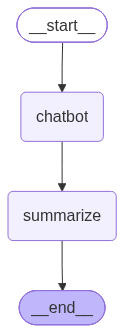

In [87]:
# visualize the graph
from IPython.display import Image
Image(graph_compile.get_graph().draw_mermaid_png())

### DAY-2(LangGraph)  Implement Parallel Workflows in LangGraph

In [17]:

# Parallel Workflow in LangGraph — Product Review Analyzer

import asyncio
import time
from typing import TypedDict, Annotated
import operator

from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",   # verify this model name is current for your account/region
    temperature=0.7,
)


In [18]:
# 1. STATE SCHEMA
class ReviewState(TypedDict):
    review_text: str
    findings: Annotated[list, operator.add]   # <-- reducer, merges parallel writes
    final_report: str

In [14]:
# 2. THE THREE PARALLEL WORKERS — each makes its own real LLM call

async def analyze_sentiment(state: ReviewState) -> dict:
    print(f"  [sentiment]  START  t={time.perf_counter():.2f}")
    prompt = f"In one short line, classify the sentiment (Positive/Negative/Mixed) of this review:\n{state['review_text']}"
    resp = await llm.ainvoke(prompt)
    print(f"  [sentiment]  END    t={time.perf_counter():.2f}")
    return {"findings": [f"Sentiment: {resp.content}"]}


async def extract_keywords(state: ReviewState) -> dict:
    print(f"  [keywords]   START  t={time.perf_counter():.2f}")
    prompt = f"List the 3-5 most important keywords/topics in this review, comma separated:\n{state['review_text']}"
    resp = await llm.ainvoke(prompt)
    print(f"  [keywords]   END    t={time.perf_counter():.2f}")
    return {"findings": [f"Keywords: {resp.content}"]}


async def summarize(state: ReviewState) -> dict:
    print(f"  [summary]    START  t={time.perf_counter():.2f}")
    prompt = f"Summarize this review in one sentence:\n{state['review_text']}"
    resp = await llm.ainvoke(prompt)
    print(f"  [summary]    END    t={time.perf_counter():.2f}")
    return {"findings": [f"Summary: {resp.content}"]}



# 3. THE JOIN / AGGREGATOR NODE (fan-in)
async def build_report(state: ReviewState) -> dict:
    print(f"  [aggregator] START  t={time.perf_counter():.2f} (all 3 branches done)")
    report = "FINAL REPORT\n" + "\n".join(f"  - {f}" for f in state["findings"])
    return {"final_report": report}


In [13]:
# 4. BUILD THE GRAPH 
graph = StateGraph(ReviewState)

graph.add_node("sentiment", analyze_sentiment)
graph.add_node("keywords", extract_keywords)
graph.add_node("summary", summarize)
graph.add_node("aggregator", build_report)

# Fan-out: START branches into all three at once
graph.add_edge(START, "sentiment")
graph.add_edge(START, "keywords")
graph.add_edge(START, "summary")

# Fan-in: all three converge on aggregator
graph.add_edge("sentiment", "aggregator")
graph.add_edge("keywords", "aggregator")
graph.add_edge("summary", "aggregator")

graph.add_edge("aggregator", END)

app = graph.compile()

In [12]:
# 5. RUN IT
async def main():
    review = "The battery lasts forever and delivery was fast, packaging was a bit crushed though."

    print("Running graph...\n")
    t0 = time.perf_counter()

    result = await app.ainvoke({"review_text": review, "findings": []})

    t1 = time.perf_counter()
    print(f"\nTotal wall-clock time: {t1 - t0:.2f}s (all 3 LLM calls ran concurrently)\n")
    print(result["final_report"])

In [10]:
await main()

Running graph...

  [keywords]   START  t=898684.50
  [sentiment]  START  t=898684.51
  [summary]    START  t=898684.51


d:\Ai Engineer_\LangGraphLearn\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


  [sentiment]  END    t=898687.39
  [keywords]   END    t=898765.61
  [summary]    END    t=898795.38
  [aggregator] START  t=898795.39 (all 3 branches done)

Total wall-clock time: 110.89s (all 3 LLM calls ran concurrently)

FINAL REPORT
  - Keywords: [{'type': 'text', 'text': 'Battery life, Delivery speed, Packaging', 'extras': {'signature': 'EvYKCvMKARFNMg82p6aa9weVrHfleFJc7uz9Cj7d4cIdxKHFwxRLx/C3yW2f4zqWbLM6QB06bapTjdxD+4G8wJ9MJZso03glbaUdcw8v3LXUPlXuy9yW2yxsKE5tk3ZH64iZOW0uu2jfPZ4/b2Ef5xO/Fi6CQuTJH8mW+XDfqSeATv4dj0fZKKyqJKu8e8VtCGtndRtM5KlvdklLvf5xqAhg77rcmQ1IKtcCNeD+hwXDDzXK8Jh7E8FLS6OiT/TZGQdtrbjY97xiNc/Pqx0v3CQD/+6LjtYAtG4J6XAx/LVx7qk4WWVVOZdVzL8ueu00vGlvBk+KVwGh7rEQbN7dssJyvhb39ikGxdGVeoGHk/Pl/SpxuPsC/qHdbFbx2TsoaWcbZDfZQAIza5zaY0P2EkFMfqkn3JCXAF4CbMwkQmbHb0OUcs5QIUKiqSlE3IXHYZVx7n0ZJbelXPJRRbv946k5hFb9ds1m1BJhyKG3eBXd8WFPEmUFW4U+5aBwzlX35WyBkN6++rpm0BqaYvADEWN0CCqMxmWEzFkO8G5TJ5UHStamK+zKv0TuwpbT1LVjSi/veeclMUHIB59tvzI0HMe/NtGGdQ1XYRVs5nVgKvZSxOf4Gm0xRfg5WhBai77SlZPZxfeGXHiUE

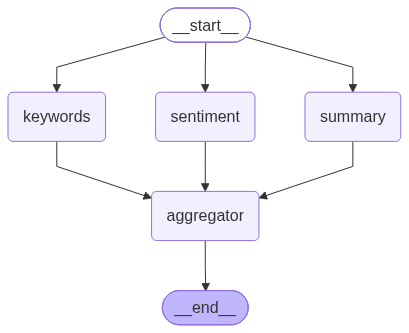

In [11]:
app


1. **Fan-out = multiple edges from one node.** If two nodes both receive an edge from the same source and don't depend on each other, LangGraph runs them at the same time. You don't call `asyncio.gather` yourself — you just draw the graph that way.

2. **Fan-in = multiple edges into one node.** That node automatically waits for every incoming branch to finish. Free synchronization, no manual join logic.

3. **Shared state written by multiple parallel branches needs a reducer.** This is the one rule that actually breaks things if you forget it. The moment two nodes write to the *same key* in the *same step*, you must tell LangGraph how to merge those writes (`operator.add`, or a custom function) — otherwise it throws a conflict error. Different keys per branch = no reducer needed. Same key = reducer required.


### Day-3
   #### Master Conditional Workflows in LangGraph

In [1]:
import os
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

In [2]:
load_dotenv()

True

In [3]:
model=ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
)

In [5]:
class SentimentSchema(BaseModel):
  sentiment:Literal["positive","negative"]=Field(description="Sentiment of the review")


class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')
  

In [9]:
structured_model=model.with_structured_output(SentimentSchema)
structured_model2=model.with_structured_output(DiagnosisSchema)

In [10]:
prompt = 'What is the sentiment of the following review - The software too bad'
structured_model2.invoke(prompt)

DiagnosisSchema(issue_type='Other', tone='disappointed', urgency='low')

In [37]:
class ReviewState(TypedDict):
  review:str
  sentiment:Literal["positive","negative"]
  diagnosis:dict
  response:str

In [12]:
def find_sentiment(state:ReviewState):
    prompt = f"What is the sentiment of the following review - {state['review']}"
    result = structured_model.invoke(prompt).sentiment
    return {"sentiment": result}

In [13]:
def positive_response(state:ReviewState):
    prompt = f"Write a positive response to the following review - {state['review']}"
    result = model.invoke(prompt)
    return {"response": result.content}

In [39]:

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

In [40]:

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}

In [47]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

In [48]:
graph=StateGraph(ReviewState)
graph.add_node("find_sentiment", find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)



graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",check_sentiment)

graph.add_edge("positive_response", END)
graph.add_edge("run_diagnosis",'negative_response')
graph.add_edge("negative_response", END)

workflow=graph.compile()


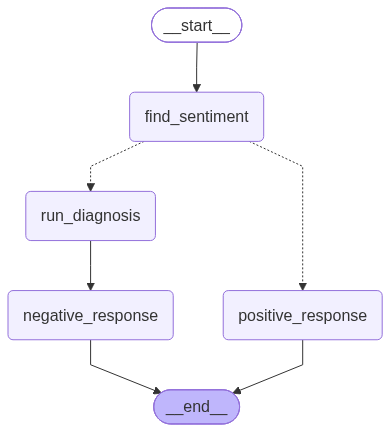

In [49]:
workflow

In [44]:
intial_state={
    'review': "Excellent software with a clean interface and smooth performance. It has improved our workflow significantly and saved a lot of time. Highly recommended for anyone looking for a reliable tech solution!"
}
result = workflow.invoke(intial_state)

In [45]:
result

{'review': 'Excellent software with a clean interface and smooth performance. It has improved our workflow significantly and saved a lot of time. Highly recommended for anyone looking for a reliable tech solution!',
 'sentiment': 'positive',
 'response': [{'type': 'text',
   'text': 'Here are a few options you can choose from, depending on your brand\'s tone:\n\n**Option 1: Professional & Warm (Best overall)**\n"Thank you so much for the fantastic review! We are thrilled to hear that our clean interface and performance have made such a positive impact on your workflow. Saving you time and providing a reliable solution is exactly what we set out to do. We truly appreciate your recommendation and look forward to continuing to support your team!"\n\n**Option 2: Short & Sweet (Great for quick replies)**\n"Thank you for the wonderful feedback! We’re delighted to know that our software is streamlining your workflow and saving you valuable time. Thanks for the high recommendation and for choo

In [50]:
intial_state={
    'review': "The software has potential, but the performance is inconsistent and the interface can be confusing at times. Frequent bugs and slow customer support made the overall experience frustrating. Needs significant improvement."
}
result = workflow.invoke(intial_state)

In [51]:
result


{'review': 'The software has potential, but the performance is inconsistent and the interface can be confusing at times. Frequent bugs and slow customer support made the overall experience frustrating. Needs significant improvement.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'medium'},
 'response': [{'type': 'text',
   'text': "**Subject:** Update on your issue: Resolution confirmed\n\nHi [User's Name],\n\nThank you for bringing this bug to our attention. I completely understand how frustrating it is when the system doesn't work as expected and interrupts what you're doing. I am very sorry for the hassle this caused you. \n\nI’m glad to let you know that our technical team has identified the root cause and deployed a fix. The issue should now be completely resolved.\n\n**To make sure the fix takes effect on your end:**\n1. Please refresh your browser (or log out and back into your account).\n2. Try [action they were attempting, e.g.

### Day-4 Iteratvie Workflows

In [15]:
generator_llm=ChatGoogleGenerativeAI(
    model="gemini-3.6-flash"
)
evaluator_llm=ChatGoogleGenerativeAI(
    model="gemini-3.6-flash"
)
optimizer_llm=ChatGoogleGenerativeAI(
    model="gemini-3.6-flash"
)

In [11]:
from pydantic import BaseModel, Field
from typing import Literal,Literal, Annotated
import operator
class PostEvaluation(BaseModel):
  evaluation:Literal["approved","needImprovement"]=Field(...,description="finl evaluation result.")
  feedback:str=Field(...,description="feedback for the generated content.")

In [5]:
structured_evaluator_llm=evaluator_llm.with_structured_output(PostEvaluation)

In [6]:
post = """
🚀 The future of AI is no longer just about answering questions — it’s about taking action.

Welcome to the era of *Agentic AI* 🤖

Agentic AI systems can plan, reason, make decisions, and execute tasks autonomously. From managing workflows and analyzing data to coordinating tools and solving complex problems, these AI agents are transforming how we work and innovate.

Imagine an AI that doesn’t just assist you — it collaborates with you.

🔹 Smarter automation
🔹 Faster decision-making
🔹 Personalized experiences
🔹 Continuous learning & adaptation

Businesses, developers, and creators who embrace Agentic AI early will shape the next generation of digital transformation.

The question is no longer *“Can AI do this?”*
It’s *“How far can AI agents go?”*

#AgenticAI #ArtificialIntelligence #AI #Automation #FutureOfWork #Innovation #TechTrends #GenerativeAI

"""


result = structured_evaluator_llm.invoke(post)

In [7]:
result.evaluation, result.feedback

('approved',
 'The post is well-structured, engaging, and effectively highlights the key benefits and future potential of Agentic AI. The use of bullet points and emojis makes it visually appealing, while the thought-provoking conclusion and relevant hashtags drive user engagement.')

In [28]:
# state
class PostState(TypedDict):

    topic: str
    post: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    post_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]


In [29]:
from langchain_core.messages import SystemMessage, HumanMessage


In [30]:
def generate_post(state:PostState):
  # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Facebook influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious Facebook post on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 200 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
    response=generator_llm.invoke(messages).content
    return {'post':response,'post_history': [response]}


In [31]:
def evaluate_post(state: PostState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Facebook critic. You evaluate posts based on humor, originality, virality, and post format."),
    HumanMessage(content=f"""
Evaluate the following Facebook post:

Post: "{state['post']}"

Use the criteria below to evaluate the post:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people share, react, or comment on it?  
5. Format – Is it a well-formed Facebook post (not a setup-punchline joke, not a Q&A joke, and under 200 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 200 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}


In [20]:
def optimize_post(state: PostState):

    messages = [
        SystemMessage(content="You punch up Facebook posts for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the Facebook post based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Post:
{state['post']}

Re-write it as a short, viral-worthy Facebook post. Avoid Q&A style and stay under 200 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'post': response, 'iteration': iteration, 'post_history': [response]}

In [32]:
def route_evaluation(state: PostState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [33]:
graph = StateGraph(PostState)

# add nodes
graph.add_node('generate', generate_post)
graph.add_node('evaluate', evaluate_post)
graph.add_node('optimize', optimize_post)


# add edges
graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate',route_evaluation,{'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

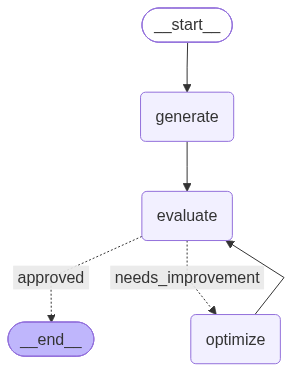

In [26]:
workflow

In [34]:
initial_state={
  "topic":"Agentic AI",
  "iteration":1,
  "max_iterations":3,
}
result=workflow.invoke(initial_state)

In [35]:
result

{'topic': 'Agentic AI',
 'post': [{'type': 'text',
   'text': 'Agentic AI is crazy. My phone just autonomously booked a 6 AM workout, paid my bills, and deleted UberEats. I am officially being bullied by code. 💀',
   'extras': {'signature': 'EtsZCtgZARFNMg9u+1rj0jVbYZmR5eJX95HnRkCDULO5JpJorXxkJ8iG3vT397Q0atbXZQR4pcYAe0BjprZBhcjZwyrMdL2mFeJOJUX/lAdF09KOpULwfDcaW8K8zoamTnA422ONEs5fweob0boyuCLgK9qTjQlQ+z/2CoSYTnOGWlgERK6F/0FEjgXAANzmI/T33U1yS048Wl6vIYTSNQT87LxzHDQUYgXm9Tm6mBUmckgwX4QTLnvdR1G1kjYzS3WydQDLmSHiPpjWZJlunEFZWkx5Ulagr8Tg1XncsarT2uEYvINwZQKW+gvrWNVzzlE5qAUR6mBDapubVgX8ehOXJUVxom5fUIhSfq+9QgcttDi6u2GPa62Z5LvmR1C0edaoiT/lOWBbG0Q0j6yQuWPz3epNX+qdwLf0FyV7GZdfxfW8tln/0Rvf4rhsiNB/lECBXRPyovzG3+QhVqO8VS5PI8kVD1sXakF+FHcDhIOQfDapBd2Qvb792fPJokyPaxV27NqjwMYwBm86c2/KUJiQa0bZNLfcnz8DW/RMfaIYQTrGOsV4i6QxB7sXz7J8lClQQ0sbHwJLcaBMaZeRItrmaRjuykRy3lhtE3X3skoS+2CKSuUuRJN+RfTQw644zHZP/X9xuAQhkXJgZjiI0A8wuE1JTIf60jzIHHUwlMn0RLs2lHgB/tQu9Ka7L5FzhGSeAIHnxMzWqaiunUdCKOcVZGYJb5bjoOgM4PRcjte5cTwvh2EE/d

In [36]:
for post in result['feedback_history']:
    print(post)

The post is concise, highly topical, and relatable, clocking in well under 200 characters with strong viral potential driven by current AI trends. It uses effective observational humor rather than a setup-punchline format, making it scroll-stopping and engaging for social media audiences.
